# Dataset composition, contributors, and validated geography

One combined publication figure (`dataset_overview`): family and dorso-ventral
composition, the top ten accepted species, the top five recorded institutions, image
counts on a validated-coordinate grid, and species diversity by validated country.

Count distinct image records using prepared accepted taxonomy and recorded GBIF institutions.
Unresolved records remain in proportion denominators. Rankings exclude unresolved species and
missing/conflicting institution attribution, with excluded counts disclosed.
Subspecies group under an accepted species where available; genus-only matches are not species.
Percentages use all images, not only the top ten. See [definitions](../README.md).


In [1]:
import sys
from pathlib import Path

ROOT = next(
    p
    for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "backend/app/configs/config.yaml").is_file()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [2]:
import matplotlib.pyplot as plt
from analyses.helpers.publication import (
    category_plot,
    load_settings,
    publication_style,
)

settings = load_settings(ROOT)
publication_style()

In [3]:
from analyses.helpers.publication import dataset_summaries

summaries = dataset_summaries(settings)

## Combined dataset overview

Panels read left to right: dorso-ventral composition (A), image providers (B) and source
aggregators (C); family composition (D) and the top ten accepted species (E); images with
validated coordinates (F) and species diversity by validated country (G).

Panel B covers every image: providers after the top five pool as “Other providers” and
unattributed or conflicting images pool separately, both in gray. Institution codes keep
their recorded capitalization. Panel C counts the recorded `source_db` aggregator; a record
carried by several aggregators keeps its combined key instead of counting under each one.

Panel F counts images with `VALID` coordinates per 100 × 100 km Equal Earth cell, on a
logarithmic scale; gray land has no validated images.

Panel G counts distinct accepted species per country (`MATCHED` taxonomy only; subspecies
group with their accepted species and genus-only matches are excluded). Countries come from
the backend coordinate-validation table (`geoharmonize integrate`), not from raw locality
fields. An image is eligible when its coordinate falls in exactly one GADM region and
nothing contradicts that region's country: either the recorded country was validated
(`COUNTRY_MATCH`, including `ADM1_MISMATCH` records, whose country is still validated) or
no country was recorded and the country is **imputed from the coordinate**
(`COUNTRY_NOT_PROVIDED`). The audit below records which of the two applies to every group,
so an imputed country is never mistaken for a recorded one. The GADM `GID_0` code is
normalized to ISO alpha-2; non-ISO GADM codes (such as `XKO` or the `Z0x` disputed areas)
resolve only through their exact, unambiguous GADM country name, otherwise they stay
unresolved. Per-reference species counts are **not additive** within a country.

The Natural Earth 110m basemap uses Equal Earth (EPSG:8857). Countries and territories
absent from its polygons use fixed-size colored markers at Natural Earth 10m label
locations; these are representative labels, not specimen coordinates.


In [ ]:
import json

from analyses.helpers.country_mapping import (
    CountryLookup,
    country_summaries,
    eligible_country_records,
)
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, PathPatch
from matplotlib.path import Path as PlotPath

map_path = ROOT / "analyses/data/ne_110m_admin_0_countries.geojson"
with map_path.open() as handle:
    countries = json.load(handle)["features"]
lookup = CountryLookup(ROOT)
country_key = lookup.feature_code
country_species, country_mapping = country_summaries(
    eligible_country_records(settings),
    countries,
    lookup,
)

unresolved = country_mapping.loc[country_mapping["representation"] == "unresolved"]
unmapped_country_images = int(unresolved["image_count"].sum())
mapped_country_images = int(country_mapping["image_count"].sum()) - unmapped_country_images
imputed_country_images = int(
    country_mapping.loc[
        (country_mapping["country_source"] == "imputed from coordinates")
        & (country_mapping["representation"] != "unresolved"),
        "image_count",
    ].sum()
)
print(f"Eligible images with a mapped country: {mapped_country_images:,}")
print(f"  of which the country was imputed from the coordinate: {imputed_country_images:,}")
print(f"Eligible images with an unresolved GADM country: {unmapped_country_images:,}")
# Display every GADM-reference-to-normalized mapping, including unresolved values.
# Species counts in this audit are per GADM reference and are not additive.
country_mapping

Eligible images with a mapped country: 459,648
  of which the country was imputed from the coordinate: 15,769
Eligible images with an unresolved GADM country: 0


,reference_code,reference_country,country_source,country_code,country_name,resolution_method,representation,mapping_source,location_source,location_feature,image_count,species_count
0,AFG,Afghanistan,imputed from coordinates,AF,Afghanistan,normalized code,polygon,geoharmonize coordinate validation (GADM GID_0...,analyses/data/ne_110m_admin_0_countries.geojson,,2,1
1,AFG,Afghanistan,validated against recorded country,AF,Afghanistan,normalized code,polygon,geoharmonize coordinate validation (GADM GID_0...,analyses/data/ne_110m_admin_0_countries.geojson,,5,4
2,AGO,Angola,validated against recorded country,AO,Angola,normalized code,polygon,geoharmonize coordinate validation (GADM GID_0...,analyses/data/ne_110m_admin_0_countries.geojson,,263,102
3,ALA,Åland,imputed from coordinates,AX,Åland Islands,normalized code,marker,geoharmonize coordinate validation (GADM GID_0...,https://raw.githubusercontent.com/nvkelso/natu...,Åland,66,13
4,ALA,Åland,validated against recorded country,AX,Åland Islands,normalized code,marker,geoharmonize coordinate validation (GADM GID_0...,https://raw.githubusercontent.com/nvkelso/natu...,Åland,3308,59
...,...,...,...,...,...,...,...,...,...,...,...,...
309,ZAF,South Africa,validated against recorded country,ZA,South Africa,normalized code,polygon,geoharmonize coordinate validation (GADM GID_0...,analyses/data/ne_110m_admin_0_countries.geojson,,2027,412
310,ZMB,Zambia,imputed from coordinates,ZM,Zambia,normalized code,polygon,geoharmonize coordinate validation (GADM GID_0...,analyses/data/ne_110m_admin_0_countries.geojson,,1,1
311,ZMB,Zambia,validated against recorded country,ZM,Zambia,normalized code,polygon,geoharmonize coordinate validation (GADM GID_0...,analyses/data/ne_110m_admin_0_countries.geojson,,87,32
312,ZWE,Zimbabwe,imputed from coordinates,ZW,Zimbabwe,normalized code,polygon,geoharmonize coordinate validation (GADM GID_0...,analyses/data/ne_110m_admin_0_countries.geojson,,27,8


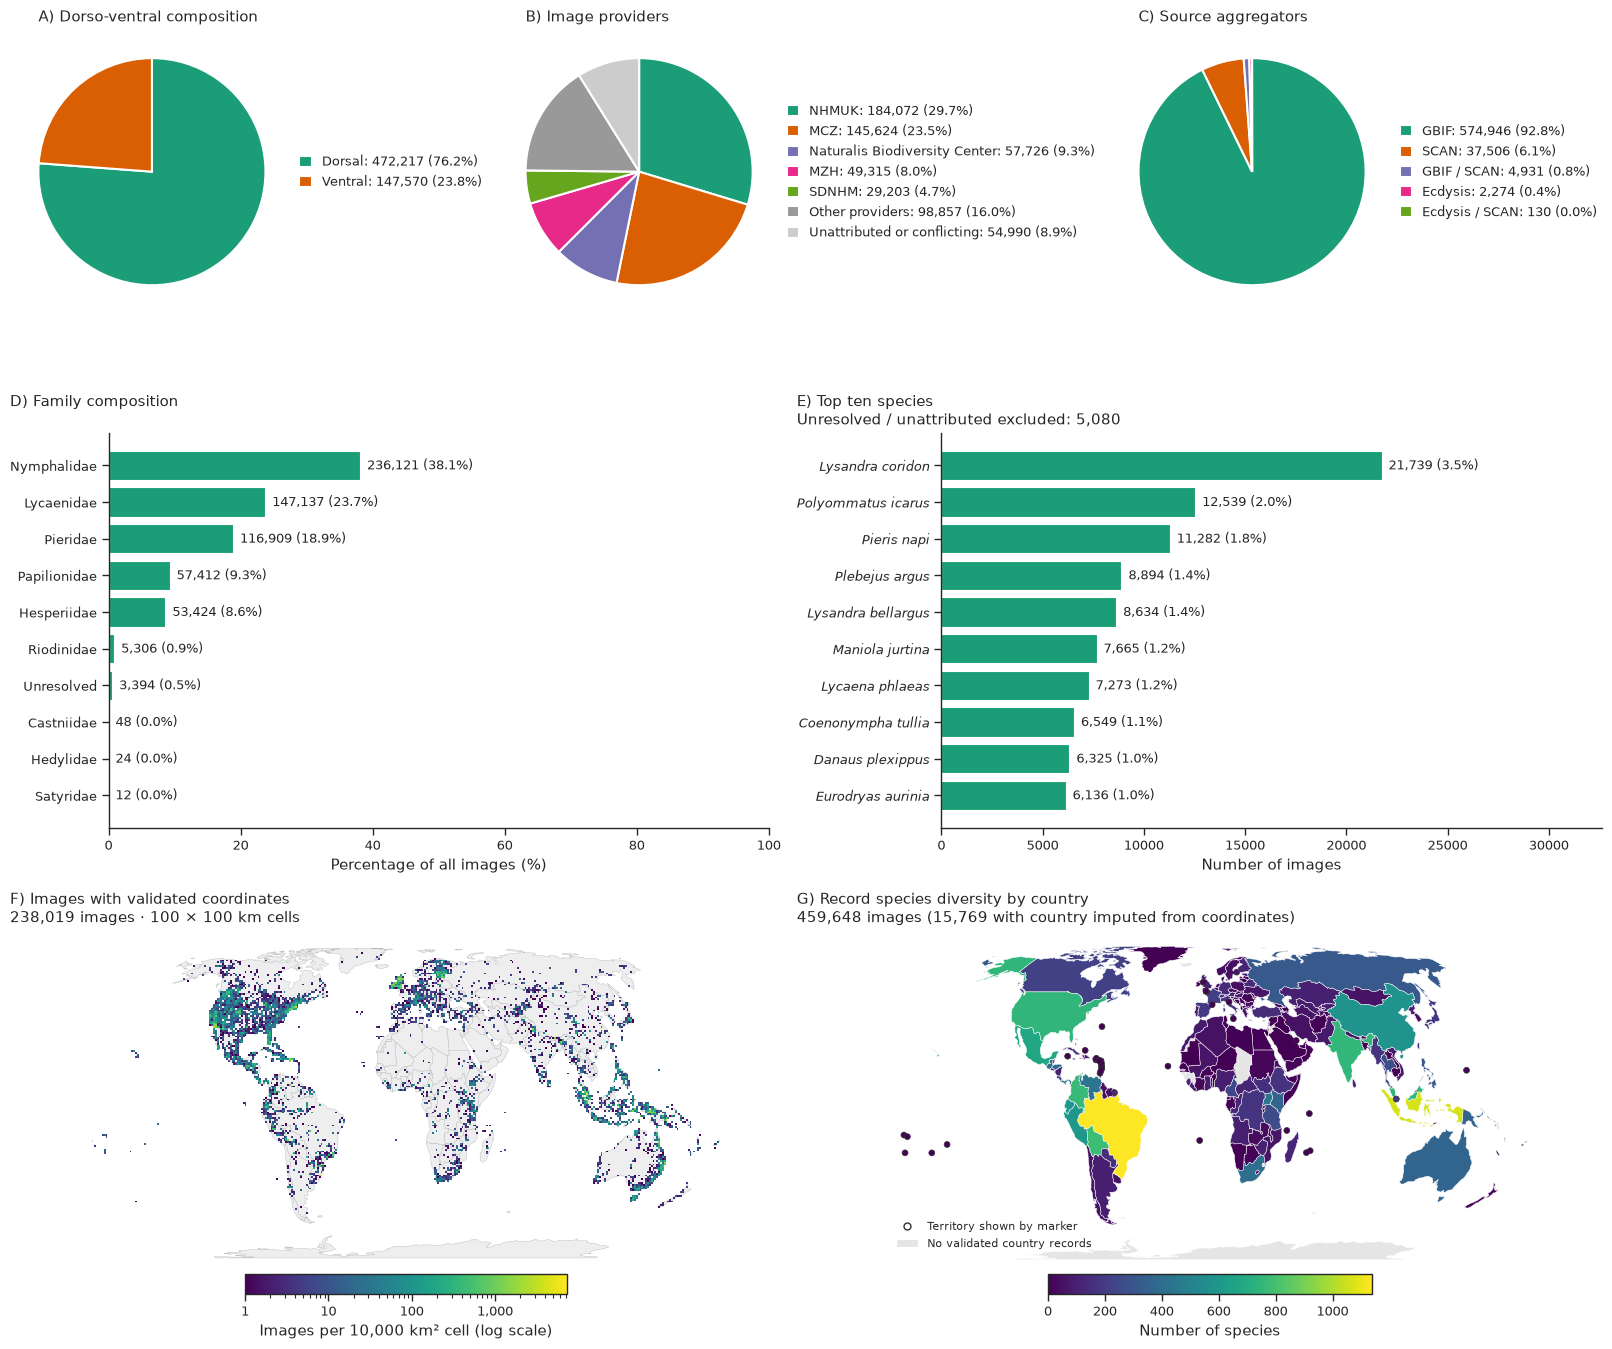

In [ ]:
from pyproj import Transformer
from analyses.helpers.grid_mapping import grid_legend, grid_map, plain_log_ticks, validated_grid
from analyses.helpers.publication import align_panel_titles, top_share

# WGS84 longitude/latitude to Equal Earth, centered on Greenwich.
# https://proj.org/en/stable/operations/projections/eqearth.html
projection = Transformer.from_crs("EPSG:4326", "EPSG:8857", always_xy=True)
map_half_width = projection.transform(180, 0)[0]
map_half_height = projection.transform(0, 90)[1]
spatial_grid = validated_grid(settings)

provider_shares = top_share(
    summaries["institutions"],
    5,
    exclude=("Unattributed", "Conflicting attribution"),
    other="Other providers",
    excluded="Unattributed or conflicting",
)

figure_width = 16
pie_height = 4
ranking_height = max(4.5, 0.32 * len(summaries["family"]) + 1.5)
map_height = figure_width / 2 * map_half_height / map_half_width
fig = plt.figure(
    figsize=(figure_width, pie_height + ranking_height + map_height + 1.2),
    layout="constrained",
)
shares_row, ranking_row, map_row = fig.subfigures(
    3, 1, height_ratios=[pie_height, ranking_height, map_height + 0.5]
)
views_ax, providers_ax, sources_ax = shares_row.subplots(1, 3)
family_ax, species_ax = ranking_row.subplots(1, 2)
map_grid = map_row.add_gridspec(2, 2, height_ratios=[map_height, 0.25])
images_map_ax = map_row.add_subplot(map_grid[0, 0])
country_map_ax = map_row.add_subplot(map_grid[0, 1])
images_bar_ax = map_row.add_subplot(map_grid[1, 0])
country_bar_ax = map_row.add_subplot(map_grid[1, 1])

category_plot(views_ax, summaries["views"], "A) Dorso-ventral composition")
# Provider codes keep their recorded capitalization (NHMUK, not Nhmuk).
category_plot(
    providers_ax,
    provider_shares,
    "B) Image providers",
    kind="pie",
    keep_case=True,
)
category_plot(
    sources_ax,
    summaries["sources"],
    "C) Source aggregators",
    kind="pie",
    keep_case=True,
)
category_plot(family_ax, summaries["family"], "D) Family composition")
category_plot(
    species_ax,
    summaries["species"],
    "E) Top ten species",
    top=10,
    exclude=("Unresolved",),
    italic=True,
    proportion=False,
)

for ax in (views_ax, providers_ax, sources_ax, family_ax, species_ax):
    heading, _, subtitle = ax.get_title(loc="left").partition("\n")
    _, separator, exclusions = subtitle.partition("; ")
    ax.set_title(heading + ("\n" + exclusions if separator else ""), loc="left", fontsize=11)

# F) Image counts in the validated-coordinate grid.
images_map = grid_map(
    images_map_ax,
    spatial_grid,
    ROOT,
    column="image_count",
    title="F) Images with validated coordinates\n"
    f"{int(spatial_grid.image_count.sum()):,} images · 100 × 100 km cells",
)
grid_legend(images_map_ax, spatial_grid, "image_count")
plain_log_ticks(
    map_row.colorbar(
        images_map,
        cax=images_bar_ax,
        orientation="horizontal",
        label="Images per 10,000 km² cell (log scale)",
    )
)

# G) Species richness by validated country.
richness = country_species.loc[country_species["mapped"]].set_index("country_code")["species_count"]
cmap = plt.get_cmap("viridis")
norm = Normalize(vmin=0, vmax=max(int(richness.max()) if not richness.empty else 0, 1))
for feature in countries:
    value = richness.get(country_key(feature))
    color = "#e5e5e5" if value is None else cmap(norm(value))
    geometry = feature["geometry"]
    if geometry is None:
        continue
    polygons = (
        geometry["coordinates"] if geometry["type"] == "MultiPolygon" else [geometry["coordinates"]]
    )
    for polygon in polygons:
        # Compound paths preserve interior rings (lakes and enclaves).
        projected_rings = [list(zip(*projection.transform(*zip(*ring)))) for ring in polygon]
        rings = [
            PlotPath(
                ring, [PlotPath.MOVETO] + [PlotPath.LINETO] * (len(ring) - 2) + [PlotPath.CLOSEPOLY]
            )
            for ring in projected_rings
        ]
        country_map_ax.add_patch(
            PathPatch(
                PlotPath.make_compound_path(*rings),
                facecolor=color,
                edgecolor="white",
                linewidth=0.35,
            )
        )
# Fixed-size markers preserve territories missing from the coarse polygons.
marker_countries = country_species.loc[country_species["representation"] == "marker"]
if not marker_countries.empty:
    locations = lookup.locations.loc[marker_countries["country_code"]]
    marker_x, marker_y = projection.transform(
        locations["longitude"].to_numpy(),
        locations["latitude"].to_numpy(),
    )
    country_map_ax.scatter(
        marker_x,
        marker_y,
        c=marker_countries["species_count"],
        cmap=cmap,
        norm=norm,
        s=18,
        edgecolors="#333333",
        linewidths=0.5,
        zorder=3,
    )
country_map_ax.legend(
    handles=[
        Line2D(
            [],
            [],
            marker="o",
            linestyle="none",
            markerfacecolor="white",
            markeredgecolor="#333333",
            markersize=5,
            label="Territory shown by marker",
        ),
        Patch(facecolor="#e5e5e5", label="No validated country records"),
    ],
    loc="lower left",
    fontsize=8,
    frameon=False,
)
country_map_ax.set_xlim(-map_half_width, map_half_width)
country_map_ax.set_ylim(-map_half_height, map_half_height)
country_map_ax.set_aspect("equal")
country_map_ax.set_axis_off()
country_map_ax.set_title(
    "G) Record species diversity by country\n"
    f"{mapped_country_images:,} images ({imputed_country_images:,} "
    "with country imputed from coordinates)",
    loc="left",
    fontsize=11,
)
map_row.colorbar(
    ScalarMappable(norm=norm, cmap=cmap),
    cax=country_bar_ax,
    orientation="horizontal",
    label="Number of species",
)

# Resolve spacing first, then freeze it, then anchor every left-aligned title to
# its own grid cell so the headings in a column line up: pies and maps shrink
# inside their cells, and the ranking panels' boxes start right of their labels.
fig.canvas.draw()
fig.set_layout_engine(None)
align_panel_titles(
    (
        views_ax,
        providers_ax,
        sources_ax,
        family_ax,
        species_ax,
        images_map_ax,
        country_map_ax,
    )
)
# Colorbars span the middle half of their map.
for map_ax, bar_ax in ((images_map_ax, images_bar_ax), (country_map_ax, country_bar_ax)):
    box, bar = map_ax.get_position(), bar_ax.get_position()
    bar_ax.set_position([box.x0 + box.width / 4, bar.y0, box.width / 2, bar.height])

# Preserve the symmetric canvas margins; tight cropping would reintroduce
# asymmetric padding from the ranking panels' tick labels.
settings.output.mkdir(parents=True, exist_ok=True)
for extension in ("pdf", "svg", "png"):
    fig.savefig(settings.output / f"dataset_overview.{extension}", dpi=300, bbox_inches=None)
for key, frame in {
    **summaries,
    "provider_shares": provider_shares,
    "cells": spatial_grid,
    "country_species": country_species,
    "country_mapping": country_mapping,
}.items():
    frame.to_csv(settings.output / f"dataset_overview_{key}.csv", index=False)
plt.show()
plt.close(fig)